In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error,root_mean_squared_error
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor

In [2]:
df = pd.read_csv('Bengaluru_House_Data.csv')
df.head(10)

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00
5,Super built-up Area,Ready To Move,Whitefield,2 BHK,DuenaTa,1170,2.0,1.0,38.00
6,Super built-up Area,18-May,Old Airport Road,4 BHK,Jaades,2732,4.0,NaN,204.00
7,Super built-up Area,Ready To Move,Rajaji Nagar,4 BHK,Brway G,3300,4.0,NaN,600.00
8,Super built-up Area,Ready To Move,Marathahalli,3 BHK,NaN,1310,3.0,1.0,63.25
9,Plot Area,Ready To Move,Gandhi Bazar,6 Bedroom,NaN,1020,6.0,NaN,370.00


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  str    
 1   availability  13320 non-null  str    
 2   location      13319 non-null  str    
 3   size          13304 non-null  str    
 4   society       7818 non-null   str    
 5   total_sqft    13320 non-null  str    
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), str(6)
memory usage: 936.7 KB


In [4]:
df.isnull().sum()

area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64

In [5]:
df = df.drop('society',axis=1)
df = df.dropna(
    subset=['location','size','bath','balcony']
)

In [6]:
df[df.duplicated()].head()

,area_type,availability,location,size,total_sqft,bath,balcony,price
971,Super built-up Area,Ready To Move,Haralur Road,3 BHK,1464,3.0,2.0,56.0
1115,Super built-up Area,Ready To Move,Haralur Road,2 BHK,1027,2.0,2.0,44.0
1143,Super built-up Area,Ready To Move,Vittasandra,2 BHK,1246,2.0,1.0,64.5
1290,Super built-up Area,Ready To Move,Haralur Road,2 BHK,1194,2.0,2.0,47.0
1394,Super built-up Area,Ready To Move,Haralur Road,2 BHK,1027,2.0,2.0,44.0


In [7]:
df.info()

<class 'pandas.DataFrame'>
Index: 12710 entries, 0 to 13319
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     12710 non-null  str    
 1   availability  12710 non-null  str    
 2   location      12710 non-null  str    
 3   size          12710 non-null  str    
 4   total_sqft    12710 non-null  str    
 5   bath          12710 non-null  float64
 6   balcony       12710 non-null  float64
 7   price         12710 non-null  float64
dtypes: float64(3), str(5)
memory usage: 893.7 KB


In [8]:
df['bhk'] = df['size'].str.split().str[0].astype(int)

In [9]:
def convert_sqft_to_num(x):

    tokens = str(x).split('-')

    if len(tokens) == 2:
        return (
            float(tokens[0]) + float(tokens[1])
        ) / 2

    try:
        return float(x)

    except:
        return None

In [10]:
df["total_sqft"] = df["total_sqft"].apply(
    convert_sqft_to_num
)

In [11]:
df["total_sqft"].isnull().sum()
df = df.dropna(subset=["total_sqft"])
df.info()

<class 'pandas.DataFrame'>
Index: 12668 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     12668 non-null  str    
 1   availability  12668 non-null  str    
 2   location      12668 non-null  str    
 3   size          12668 non-null  str    
 4   total_sqft    12668 non-null  float64
 5   bath          12668 non-null  float64
 6   balcony       12668 non-null  float64
 7   price         12668 non-null  float64
 8   bhk           12668 non-null  int64  
dtypes: float64(4), int64(1), str(4)
memory usage: 989.7 KB


In [12]:
df = df.drop("size", axis=1)
df["availability"] = df["availability"].apply(
    lambda x: "Ready" if x == "Ready To Move" else "Future"
)

In [13]:
df.head(10)

,area_type,availability,location,total_sqft,bath,balcony,price,bhk
0,Super built-up Area,Future,Electronic City Phase II,1056.0,2.0,1.0,39.07,2
1,Plot Area,Ready,Chikka Tirupathi,2600.0,5.0,3.0,120.00,4
2,Built-up Area,Ready,Uttarahalli,1440.0,2.0,3.0,62.00,3
3,Super built-up Area,Ready,Lingadheeranahalli,1521.0,3.0,1.0,95.00,3
4,Super built-up Area,Ready,Kothanur,1200.0,2.0,1.0,51.00,2
5,Super built-up Area,Ready,Whitefield,1170.0,2.0,1.0,38.00,2
8,Super built-up Area,Ready,Marathahalli,1310.0,3.0,1.0,63.25,3
10,Super built-up Area,Future,Whitefield,1800.0,2.0,2.0,70.00,3
11,Plot Area,Ready,Whitefield,2785.0,5.0,3.0,295.00,4
12,Super built-up Area,Ready,7th Phase JP Nagar,1000.0,2.0,1.0,38.00,2


In [14]:
df = df[df["bhk"] <= 10]
df = df[df["bath"] <= df["bhk"] + 2]

In [15]:
df[df["total_sqft"] > 10000]

,area_type,availability,location,total_sqft,bath,balcony,price,bhk
408,Super built-up Area,Future,Rajaji Nagar,12000.0,6.0,3.0,2200.0,7
440,Plot Area,Ready,Whitefield,11890.0,4.0,3.0,700.0,4
605,Super built-up Area,Future,Malleshwaram,12000.0,7.0,3.0,2200.0,7
674,Built-up Area,Ready,Yelahanka,35000.0,3.0,3.0,130.0,3
810,Plot Area,Future,4 Bedroom Farm House in Bagalur,10961.0,4.0,1.0,80.0,4
1234,Plot Area,Ready,Siddapura,14000.0,3.0,2.0,800.0,4
1894,Plot Area,Ready,Nelamangala,52272.0,2.0,1.0,140.0,3
5393,Super built-up Area,Ready,Doddabommasandra,42000.0,8.0,3.0,175.0,9
5469,Super built-up Area,Ready,Ulsoor,36000.0,4.0,2.0,450.0,4
7242,Plot Area,Ready,Yelahanka,26136.0,1.0,0.0,150.0,1


In [16]:
df["price_per_sqft"] = (
    df["price"] * 100000
) / df["total_sqft"]

In [17]:
df[df["total_sqft"] > 10000]

,area_type,availability,location,total_sqft,bath,balcony,price,bhk,price_per_sqft
408,Super built-up Area,Future,Rajaji Nagar,12000.0,6.0,3.0,2200.0,7,18333.333333
440,Plot Area,Ready,Whitefield,11890.0,4.0,3.0,700.0,4,5887.300252
605,Super built-up Area,Future,Malleshwaram,12000.0,7.0,3.0,2200.0,7,18333.333333
674,Built-up Area,Ready,Yelahanka,35000.0,3.0,3.0,130.0,3,371.428571
810,Plot Area,Future,4 Bedroom Farm House in Bagalur,10961.0,4.0,1.0,80.0,4,729.860414
1234,Plot Area,Ready,Siddapura,14000.0,3.0,2.0,800.0,4,5714.285714
1894,Plot Area,Ready,Nelamangala,52272.0,2.0,1.0,140.0,3,267.829813
5393,Super built-up Area,Ready,Doddabommasandra,42000.0,8.0,3.0,175.0,9,416.666667
5469,Super built-up Area,Ready,Ulsoor,36000.0,4.0,2.0,450.0,4,1250.000000
7242,Plot Area,Ready,Yelahanka,26136.0,1.0,0.0,150.0,1,573.921028


In [18]:
location_counts = df["location"].value_counts()
location_counts

location
Whitefield                                         513
Sarjapur  Road                                     372
Electronic City                                    300
Kanakpura Road                                     259
Thanisandra                                        229
                                                  ... 
Pattegarhpalya                                       1
Tilak Nagar                                          1
12th cross srinivas nagar banshankari 3rd stage      1
Havanur extension                                    1
Abshot Layout                                        1
Name: count, Length: 1253, dtype: int64

In [19]:
rare_locations = location_counts[
    location_counts <= 10
].index
df["location"] = df["location"].apply(
    lambda x: "other"
    if x in rare_locations
    else x
)

In [20]:
df = df[
    (df["price_per_sqft"] > 1000) &
    (df["price_per_sqft"] < 50000)
]

In [21]:
df["location"].nunique()

236

In [22]:
df = df.drop(
    ["price_per_sqft", "sqft_per_bhk"],
    axis=1,
    errors="ignore"
)

In [23]:
df.corr(numeric_only=True)

,total_sqft,bath,balcony,price,bhk
total_sqft,1.000000,0.501259,0.187307,0.708396,0.438880
bath,0.501259,1.000000,0.229450,0.483542,0.872747
balcony,0.187307,0.229450,1.000000,0.121441,0.212651
price,0.708396,0.483542,0.121441,1.000000,0.430338
bhk,0.438880,0.872747,0.212651,0.430338,1.000000


In [24]:
X = df.drop("price", axis=1)

y = df["price"]

In [25]:
x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [26]:
df.info()

<class 'pandas.DataFrame'>
Index: 12633 entries, 0 to 13319
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     12633 non-null  str    
 1   availability  12633 non-null  str    
 2   location      12633 non-null  str    
 3   total_sqft    12633 non-null  float64
 4   bath          12633 non-null  float64
 5   balcony       12633 non-null  float64
 6   price         12633 non-null  float64
 7   bhk           12633 non-null  int64  
dtypes: float64(4), int64(1), str(3)
memory usage: 888.3 KB


In [27]:
categorical_cols = [
    "location", "availability", "area_type"
]
numerical_cols = [
    "bath", "balcony", "bhk", "total_sqft"
]


In [28]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

In [29]:
lr = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

In [30]:
pipline = Pipeline(
    steps=[
        ('preprocessor',preprocessor),
        ('model',lr)
    ]
)

In [31]:
pipline.fit(x_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [32]:
y_pred = pipline.predict(x_test)

In [33]:
y_pred

array([47.13299919, 48.7541693 , 74.18651316, ..., 56.17660525,
       44.22953171, 48.02403371], shape=(2527,))

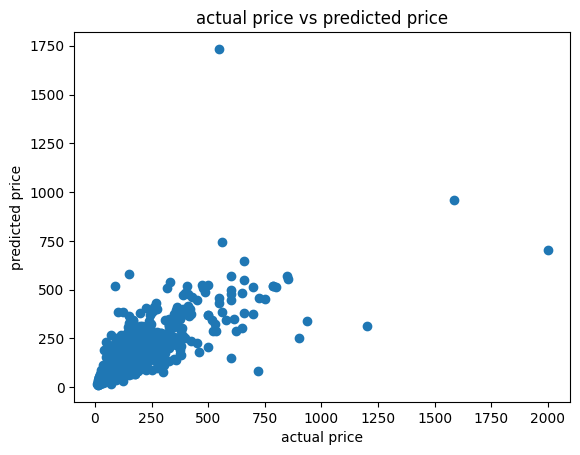

In [34]:
plt.scatter(y_test,y_pred)
plt.xlabel("actual price")
plt.ylabel("predicted price")
plt.title("actual price vs predicted price")
plt.show()

In [35]:
print(r2_score(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))
print(root_mean_squared_error(y_test,y_pred))

0.6332065970419454
4602.367996408688
67.84075468631438


In [36]:
y_test

13022     35.00
8922      20.00
11821     75.00
3150     105.00
5025      94.55
          ...  
931       49.86
5802     145.00
11385     56.00
1600      37.50
2018      54.00
Name: price, Length: 2527, dtype: float64

In [37]:
test_data = pd.DataFrame({
    "area_type": ["Super built-up  Area"],
    "availability": ["Ready"],
    "location": ["Bannerghatta Road"],
    "total_sqft": [1022.0],
    "bath": [2.0],
    "balcony": [1.0],
    "bhk": [2]
})

In [38]:
prediction = pipline.predict(test_data)

print("Predicted Price:", prediction[0], "Lakhs")

Predicted Price: 47.13299919039904 Lakhs


In [39]:
import joblib

joblib.dump(pipline, "benguluru_model.pkl")

['benguluru_model.pkl']